<a href="https://colab.research.google.com/github/KarimAhmedAI/mnist-digit-classifier/blob/main/mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

In [2]:
mnist=tf.keras.datasets.mnist

In [3]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [9]:
es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [10]:
model.fit(x_train,y_train,epochs=10,batch_size=32,validation_split=0.2,callbacks=[es])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8790 - loss: 0.4022 - val_accuracy: 0.9566 - val_loss: 0.1503
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9390 - loss: 0.2080 - val_accuracy: 0.9620 - val_loss: 0.1316
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9511 - loss: 0.1622 - val_accuracy: 0.9632 - val_loss: 0.1210
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9583 - loss: 0.1362 - val_accuracy: 0.9675 - val_loss: 0.1027
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9624 - loss: 0.1239 - val_accuracy: 0.9721 - val_loss: 0.0931
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9657 - loss: 0.1120 - val_accuracy: 0.9728 - val_loss: 0.0917
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9687 - loss: 0.1029 - val_accuracy: 0.9744 - val_loss: 0.0866
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9695 - loss: 0.0961 

In [11]:
loss,acc=model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.0874


In [12]:
print("Loss:", loss)
print("Accuracy:", acc)

Loss: 0.08737150579690933
Accuracy: 0.9768000245094299


In [13]:
pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


y_pred = 7
y_actual = 7


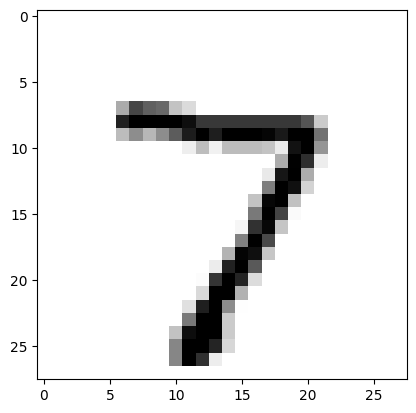

In [22]:
import numpy as np
import matplotlib.pyplot as plt
print('y_pred =',np.argmax(pred[0]))
print('y_actual =',y_test[0])
plt.imshow(x_test[0],cmap='binary')